# Baseline Model

Train a vanilla baseline CatBoost model using only the main Home Credit application table.

No bureau, previous application, POS, installment, credit-card tables, or engineered feature files are used here. The goal is a clean baseline against the full project pipeline. Artifacts are saved to `Models/baseline/`.

In [1]:
from pathlib import Path
import json
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import yaml

from catboost import CatBoostClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split


In [2]:
cwd = Path.cwd().resolve()
project_root = cwd.parent if cwd.name.lower() == "notebooks" else cwd
config_path = project_root / "config.yaml"

with open(config_path, "r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

raw_paths = config["data"]["raw"]
target_col = config["training"]["target_col"]
id_col = config["training"]["id_col"]
seed = config["globals"]["random_state"]

train_path = project_root / raw_paths["application_train"]
test_path = project_root / raw_paths["application_test"]
baseline_dir = project_root / config["training"]["artifact_paths"]["models_dir"] / "baseline"
baseline_dir.mkdir(parents=True, exist_ok=True)

print(f"Train path: {train_path}")
print(f"Test path: {test_path}")
print(f"Artifacts: {baseline_dir}")


Train path: C:\Projects\Machine leanrign ITI project\Home-Credit-Default-Risk-ML\Data\Raw\application_train.csv
Test path: C:\Projects\Machine leanrign ITI project\Home-Credit-Default-Risk-ML\Data\Raw\application_test.csv
Artifacts: C:\Projects\Machine leanrign ITI project\Home-Credit-Default-Risk-ML\Models\baseline


## Load Vanilla Application Tables

Only `application_train.csv` and `application_test.csv` are loaded. The notebook drops `TARGET` and `SK_ID_CURR` for modeling, but does not merge other tables or create project pipeline features.

In [3]:
application_train = pd.read_csv(train_path)
application_test = pd.read_csv(test_path)

if target_col not in application_train.columns:
    raise ValueError(f"{target_col} not found in application_train.csv")
if target_col in application_test.columns:
    raise ValueError(f"{target_col} should not be present in application_test.csv")

y = application_train[target_col]
X = application_train.drop(columns=[target_col, id_col])
X_test_final = application_test.drop(columns=[id_col])
test_ids = application_test[id_col]

print("Train features:", X.shape)
print("Test features:", X_test_final.shape)
print("Default rate:", y.mean())


Train features: (307511, 120)
Test features: (48744, 120)
Default rate: 0.08072881945686496


In [4]:
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

for col in categorical_cols:
    X[col] = X[col].astype("string").fillna("__MISSING__")
    X_test_final[col] = X_test_final[col].astype("string").fillna("__MISSING__")

cat_features = [X.columns.get_loc(col) for col in categorical_cols]
print(f"Categorical columns: {len(categorical_cols)}")


Categorical columns: 16


## Train/Validation Split

The validation score is a simple stratified holdout baseline. It is not the full project's OOF validation.

In [5]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=seed,
)

model_config = next(
    candidate for candidate in config["training"]["models"]["candidates"]
    if candidate["name"] == "catboost"
)
model_params = model_config["params"].copy()
early_stopping_rounds = model_params.pop("early_stopping_rounds", None)
model_params.pop("eval_fraction", None)
model_params.update(config["training"]["preprocessing"]["imbalance"]["class_weight_params"].get("catboost", {}))

validation_model = CatBoostClassifier(
    cat_features=cat_features,
    eval_metric="AUC",
    random_seed=seed,
    verbose=100,
    **model_params,
)

fit_kwargs = {"eval_set": (X_valid, y_valid)}
if early_stopping_rounds:
    fit_kwargs["early_stopping_rounds"] = early_stopping_rounds

validation_model.fit(X_train, y_train, **fit_kwargs)


0:	test: 0.6956750	best: 0.6956750 (0)	total: 272ms	remaining: 4m 31s


100:	test: 0.7474459	best: 0.7474459 (100)	total: 14.4s	remaining: 2m 8s


200:	test: 0.7537499	best: 0.7537707 (199)	total: 29s	remaining: 1m 55s


300:	test: 0.7582736	best: 0.7582736 (300)	total: 44.2s	remaining: 1m 42s


400:	test: 0.7608198	best: 0.7608398 (399)	total: 58.1s	remaining: 1m 26s


...

700:	test: 0.7630818	best: 0.7631208 (697)	total: 3m 12s	remaining: 1m 21s


800:	test: 0.7635757	best: 0.7635757 (800)	total: 3m 56s	remaining: 58.7s


900:	test: 0.7636113	best: 0.7637041 (856)	total: 4m 33s	remaining: 30.1s


Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.763704134
bestIteration = 856

Shrink model to first 857 iterations.


CatBoostClassifier(allow_writing_files=False, auto_class_weights='Balanced', bootstrap_type='Bernoulli', cat_features=[0, 1, 2, 3, 9, 10, 11, 12, 13, 26, 30, 38, 84, 85, 87, 88], depth=6, eval_metric='AUC', iterations=1000, learning_rate=0.05, random_seed=42, rsm=0.8, verbose=100)

In [6]:
valid_proba = validation_model.predict_proba(X_valid)[:, 1]
valid_pred = (valid_proba >= 0.5).astype(int)

metrics = {
    "scope": "vanilla_application_holdout",
    "roc_auc": float(roc_auc_score(y_valid, valid_proba)),
    "average_precision": float(average_precision_score(y_valid, valid_proba)),
    "classification_threshold": 0.5,
    "train_rows": int(len(X_train)),
    "valid_rows": int(len(X_valid)),
    "feature_count": int(X.shape[1]),
    "categorical_feature_count": int(len(categorical_cols)),
}

report = classification_report(y_valid, valid_pred, zero_division=0)
conf_matrix = confusion_matrix(y_valid, valid_pred)

print(json.dumps(metrics, indent=2))
print(report)


{
  "scope": "vanilla_application_holdout",
  "roc_auc": 0.7637041340392688,
  "average_precision": 0.25217424716394604,
  "classification_threshold": 0.5,
  "train_rows": 246008,
  "valid_rows": 61503,
  "feature_count": 120,
  "categorical_feature_count": 16
}
              precision    recall  f1-score   support

           0       0.96      0.72      0.82     56538
           1       0.17      0.67      0.28      4965

    accuracy                           0.72     61503
   macro avg       0.57      0.70      0.55     61503
weighted avg       0.90      0.72      0.78     61503



## Fit Final Baseline And Save Artifacts

The final baseline model is fit on the full vanilla application training table. The validation model's best iteration is reused when available.

In [7]:
final_params = model_params.copy()
best_iteration = validation_model.get_best_iteration()
if best_iteration is not None and best_iteration > 0:
    final_params["iterations"] = best_iteration + 1

final_model = CatBoostClassifier(
    cat_features=cat_features,
    eval_metric="AUC",
    random_seed=seed,
    verbose=100,
    **final_params,
)
final_model.fit(X, y)

submission = pd.DataFrame({
    id_col: test_ids,
    target_col: final_model.predict_proba(X_test_final)[:, 1],
})

joblib.dump(final_model, baseline_dir / "final_model.pkl")
submission.to_csv(baseline_dir / "submission.csv", index=False)

with open(baseline_dir / "metrics.yaml", "w", encoding="utf-8") as file:
    yaml.safe_dump(metrics, file, sort_keys=False)

with open(baseline_dir / "evaluation_report.txt", "w", encoding="utf-8") as file:
    file.write("Baseline CatBoost on raw application table only\n")
    file.write("=" * 48 + "\n")
    file.write(json.dumps(metrics, indent=2))
    file.write("\n\nClassification report @ 0.5 threshold\n")
    file.write(report)

with open(baseline_dir / "config_snapshot.yaml", "w", encoding="utf-8") as file:
    yaml.safe_dump(config, file, sort_keys=False)

print(f"Saved baseline artifacts to {baseline_dir}")


0:	total: 429ms	remaining: 6m 7s


100:	total: 43.7s	remaining: 5m 27s


200:	total: 1m 27s	remaining: 4m 45s


300:	total: 1m 49s	remaining: 3m 22s


400:	total: 2m 4s	remaining: 2m 21s


...

600:	total: 2m 34s	remaining: 1m 5s


700:	total: 2m 50s	remaining: 37.9s


800:	total: 3m 6s	remaining: 13s


856:	total: 3m 15s	remaining: 0us


Saved baseline artifacts to C:\Projects\Machine leanrign ITI project\Home-Credit-Default-Risk-ML\Models\baseline


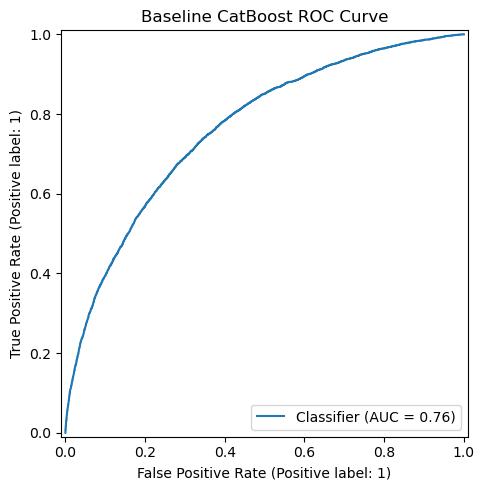

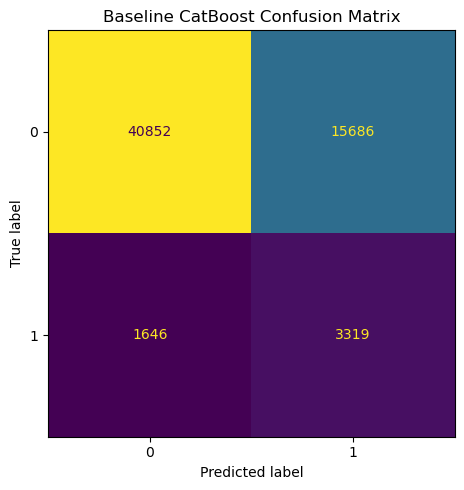

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_valid, valid_proba, ax=ax)
ax.set_title("Baseline CatBoost ROC Curve")
fig.tight_layout()
fig.savefig(baseline_dir / "roc_curve.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=conf_matrix).plot(ax=ax, colorbar=False)
ax.set_title("Baseline CatBoost Confusion Matrix")
fig.tight_layout()
fig.savefig(baseline_dir / "confusion_matrix.png", dpi=160)
plt.show()


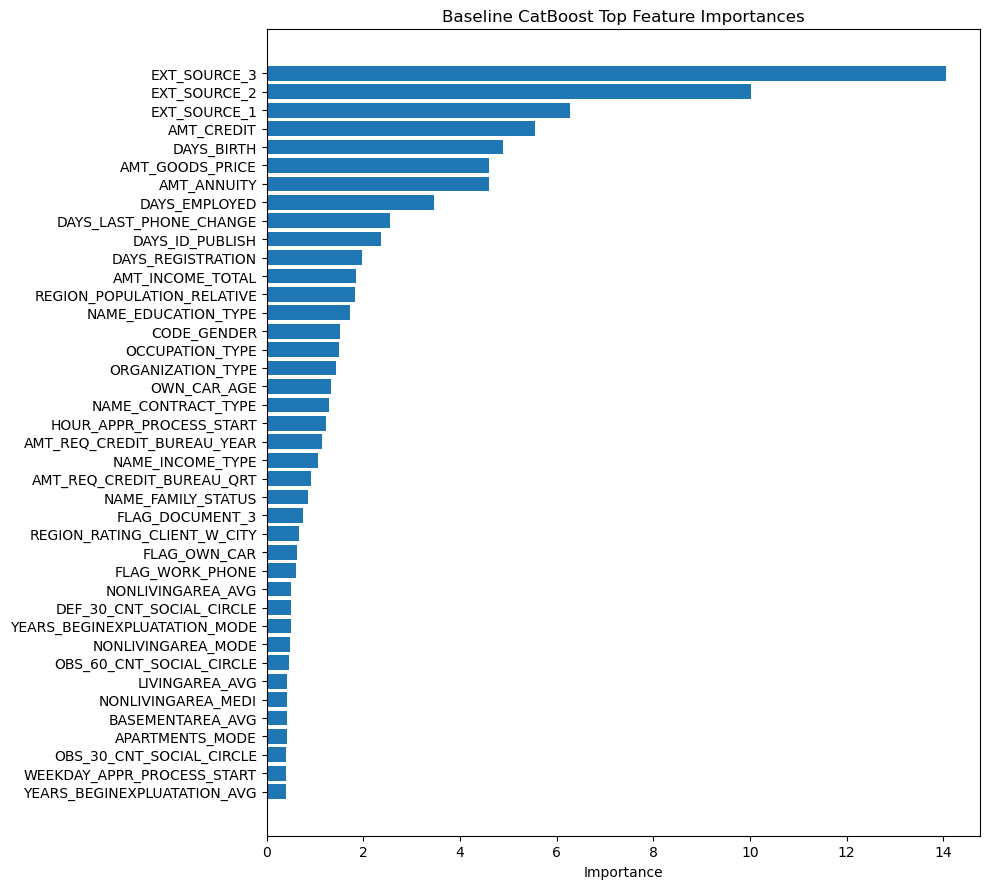

,feature,importance
41,EXT_SOURCE_3,14.057635
40,EXT_SOURCE_2,10.029432
39,EXT_SOURCE_1,6.270727
6,AMT_CREDIT,5.546141
15,DAYS_BIRTH,4.882385
8,AMT_GOODS_PRICE,4.599183
7,AMT_ANNUITY,4.595636
16,DAYS_EMPLOYED,3.461845
93,DAYS_LAST_PHONE_CHANGE,2.545338
18,DAYS_ID_PUBLISH,2.354480


In [9]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": final_model.get_feature_importance(),
}).sort_values("importance", ascending=False)
feature_importance.to_csv(baseline_dir / "feature_importance.csv", index=False)

top = feature_importance.head(40).sort_values("importance", ascending=True)
fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(top["feature"], top["importance"])
ax.set_title("Baseline CatBoost Top Feature Importances")
ax.set_xlabel("Importance")
fig.tight_layout()
fig.savefig(baseline_dir / "feature_importance_top.png", dpi=160)
plt.show()

feature_importance.head(20)
